# **Hand Written Digits classification**

## Importing neccessary libraries

In [168]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

### Loading dataset and reviewing its shapes

In [169]:
digits = load_digits()

print(digits.data.shape)
print(digits.images.shape)


(1797, 64)
(1797, 8, 8)


## Visualizing the data

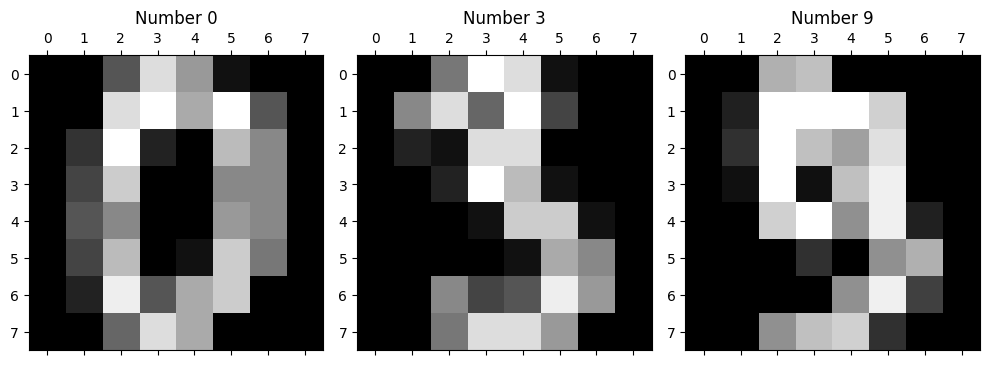

In [170]:
fig,ax = plt.subplots(nrows=1,ncols=3,figsize=(10,10))

plt.gray()

ax[0].set_title("Number 0")
ax[0].matshow(digits.images[0])

ax[1].set_title("Number 3")
ax[1].matshow(digits.images[3])

ax[2].set_title("Number 9")
ax[2].matshow(digits.images[9])

plt.tight_layout()
plt.show()


## Extracting features and label and converting its data type

In [171]:
X = digits.data
y = digits.target

# Changing the dataset into tensor
X = torch.from_numpy(X).type(torch.float)
y= torch.from_numpy(y).type(torch.float)

## Spliting the dataset into training and testing

In [172]:
# Spliting the dataset into train and test batch
torch.manual_seed(42)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


## Setting the device to GPU if available

In [173]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## Defining main model class


In [174]:
# Defining the model

class digitClassification(nn.Module):

  def __init__(self):
    super().__init__()

    self.layers = nn.Sequential(
          nn.Linear(in_features=64,out_features=128),
          nn.ReLU(),
          nn.Linear(in_features=128,out_features=128),
          nn.ReLU(),
          nn.Linear(in_features=128,out_features=10)
    )

  def forward(self,X):
    return self.layers(X)



## Making instance and evaluating initially

In [175]:
# Instansiate model

model1 = digitClassification().to(device)

X_train,X_test = X_train.to(device), X_test.to(device)
y_train,y_test = y_train.to(device), y_test.to(device)


# trying to predict randomly to see if the model works

model1.eval()
with torch.inference_mode():
  y_logits = model1(X_train[:5])
  print(y_logits)
  y_preds_prob = torch.softmax(y_logits,dim=-1)
  print(y_preds_prob)
  y_preds = torch.argmax(y_preds_prob,dim=-1)

y_preds

tensor([[ 0.8825, -0.0260, -0.7121, -0.0089, -1.0369,  1.2023,  0.0883, -0.0735,
          0.3635, -0.8589],
        [ 0.5145, -0.0347, -0.4888, -0.0369, -0.4707,  0.8808,  0.5112, -0.3348,
          0.3945, -0.0086],
        [ 0.4111,  0.6315, -0.9177, -0.5834, -0.9749,  1.1170,  0.5141, -0.7817,
         -0.1672, -0.1110],
        [ 0.4565, -0.2813, -0.8312, -0.0530, -0.4427,  0.5452,  0.5503,  0.3159,
         -0.3897, -0.5491],
        [ 0.6091,  0.3507, -0.9746, -0.0653, -0.7446,  0.7763,  0.7738, -0.3366,
          0.0653, -0.1431]], device='cuda:0')
tensor([[0.1943, 0.0783, 0.0394, 0.0797, 0.0285, 0.2675, 0.0878, 0.0747, 0.1156,
         0.0341],
        [0.1381, 0.0798, 0.0506, 0.0796, 0.0516, 0.1992, 0.1377, 0.0591, 0.1225,
         0.0819],
        [0.1295, 0.1614, 0.0343, 0.0479, 0.0324, 0.2623, 0.1435, 0.0393, 0.0726,
         0.0768],
        [0.1511, 0.0723, 0.0417, 0.0908, 0.0615, 0.1652, 0.1660, 0.1313, 0.0648,
         0.0553],
        [0.1528, 0.1180, 0.0313, 0.0778, 

tensor([5, 5, 5, 6, 5], device='cuda:0')

## Initializing loss function and optimizer

In [176]:
# Defining loss function and optimizer

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params = model1.parameters(),
                            lr=0.03)

## Accuracy Function

In [177]:
# Accuracy function

def accuracy_fn(y_true,y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  acc = (correct/len(y_pred)) * 100
  return acc

## Training and evaluating loop

In [178]:
# Training loop

epochs = 1000
train_losses = dict()
test_losses = dict()
for epoch in range(epochs):

  #Setting model into training mode
  model1.train()

  #feeding data to the model
  train_logits = model1(X_train)
  train_preds = torch.argmax(torch.softmax(train_logits,dim=-1),dim=-1)

  #calculating loss
  loss = loss_fn(train_logits,y_train.long())
  train_losses[epoch]=loss.item()
  #calculating accuracy
  accuracy = accuracy_fn(y_true=y_train,y_pred=train_preds)

  #re-setting gradient of optimizer
  optimizer.zero_grad()

  #backpropagation
  loss.backward()

  #adjusting the weights of the model
  optimizer.step()

  if epoch%100==0:

    model1.eval()
    with torch.inference_mode():
      test_logits = model1(X_test)
      test_pred = torch.argmax(torch.softmax(test_logits,dim=-1),dim=-1)
      test_loss = loss_fn(test_logits,y_test.long())
      test_losses[epoch] = test_loss.item()
      test_accuracy = accuracy_fn(y_true = y_test,
                                  y_pred = test_pred)


    print(f"The training loss {loss:.5f} | accuracy: {accuracy:.2f}%")
    print(f"The testing loss {test_loss:.5f} | accuracy: {test_accuracy:.2f}%")

The training loss 2.45348 | accuracy: 8.21%
The testing loss 2.19291 | accuracy: 19.72%
The training loss 0.13643 | accuracy: 97.43%
The testing loss 0.14138 | accuracy: 96.67%
The training loss 0.07043 | accuracy: 99.10%
The testing loss 0.09501 | accuracy: 97.22%
The training loss 0.04534 | accuracy: 99.58%
The testing loss 0.08172 | accuracy: 98.33%
The training loss 0.03230 | accuracy: 99.72%
The testing loss 0.07662 | accuracy: 98.33%
The training loss 0.02434 | accuracy: 99.79%
The testing loss 0.07466 | accuracy: 98.33%
The training loss 0.01904 | accuracy: 99.79%
The testing loss 0.07409 | accuracy: 98.61%
The training loss 0.01535 | accuracy: 99.86%
The testing loss 0.07422 | accuracy: 98.61%
The training loss 0.01268 | accuracy: 99.93%
The testing loss 0.07471 | accuracy: 98.61%
The training loss 0.01069 | accuracy: 100.00%
The testing loss 0.07516 | accuracy: 98.61%


## Loss visualizing function


In [195]:
def plot_loss(ax, title, losses):
  # Use ax methods instead of global plt methods
  ax.set_title(f"{title} Loss vs Iteration")
  ax.set_ylabel("Loss")
  ax.set_xlabel("Itteration")
  ax.plot(list(losses.keys()), list(losses.values()))

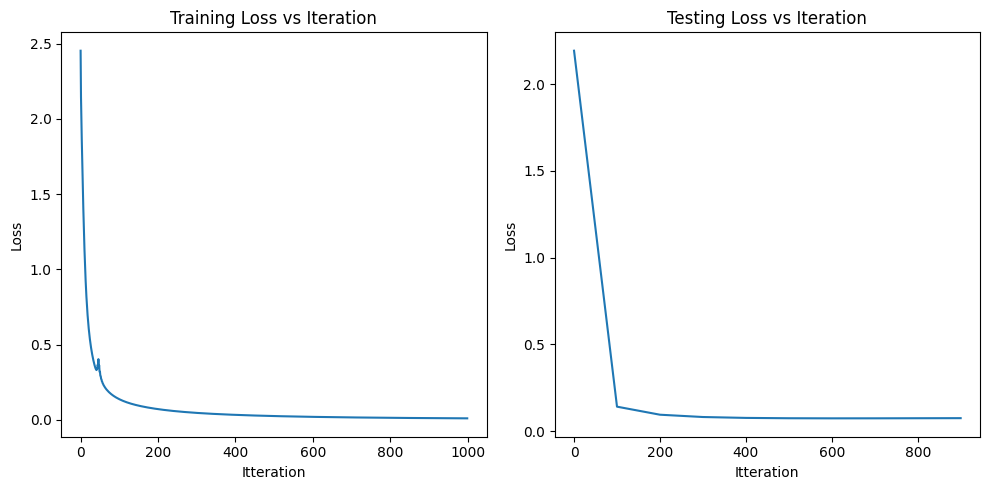

In [196]:
# Create subplots
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

# Pass the respective axis to the plotting function
plot_loss(ax[0], "Training", train_losses)
plot_loss(ax[1], "Testing", test_losses)

plt.tight_layout()
plt.show()

# Testing model for specific numbers

### For Number 8

Testing the model if it can predict the following number


<Figure size 640x480 with 0 Axes>

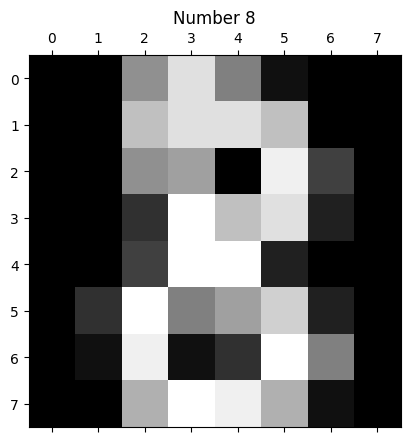

--------------------------------------------------------------------------------
Feeding model the data of this image
--------------------------------------------------------------------------------
The prediction of the model is:  8


In [192]:
# Evaluating the model

print("Testing the model if it can predict the following number")

plt.gray()
plt.matshow(digits.images[8])
plt.title("Number 8")
plt.show()

print("----"*20)
print("Feeding model the data of this image")

number_8 = torch.from_numpy(digits.data[8]).type(torch.float).to(device)

model1.eval()
with torch.inference_mode():
  number_8_logits = model1(number_8)
  prediction = torch.argmax(torch.softmax(number_8_logits,dim=-1),dim=-1)

print("----"*20)
print("The prediction of the model is: ",prediction.item())

### For Number 4

Testing the model if it can predict the following number


<Figure size 640x480 with 0 Axes>

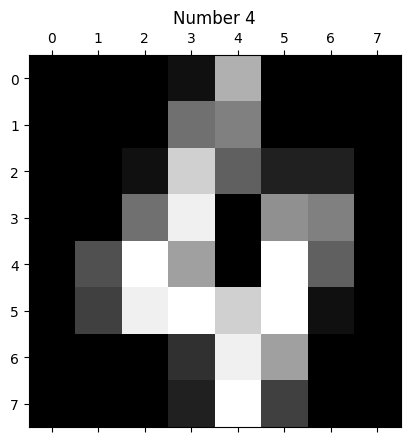

--------------------------------------------------------------------------------
Feeding model the data of this image
--------------------------------------------------------------------------------
The prediction of the model is:  4


In [193]:
# Evaluating the model

print("Testing the model if it can predict the following number")

plt.gray()
plt.matshow(digits.images[4])
plt.title("Number 4")
plt.show()

print("----"*20)
print("Feeding model the data of this image")

number_4 = torch.from_numpy(digits.data[4]).type(torch.float).to(device)

model1.eval()
with torch.inference_mode():
  number_4_logits = model1(number_4)
  prediction = torch.argmax(torch.softmax(number_4_logits,dim=-1),dim=-1)

print("----"*20)
print("The prediction of the model is: ",prediction.item())

## Saving the models parameters So we can use later

In [194]:

path = "Hand_written_digits_classification.pth"

torch.save(model1.state_dict(),path)